Malaika
23-NTU-CS-1291
LAB12(Kmeans-Clustering)

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

ACTIVITY 2

In [69]:
#Activity 2(Load Dataset)
df=pd.read_csv("customer_big_dataset.csv")
df.head()

,CustomerID,AGE,AnnualIncome,SpendingScore,City,VisitFrequency,OnlinePurchaseRatio,EducationLevel,FamilySize
0,1,22,35000,40,CityA,12,0.3,2,4
1,2,25,42000,48,CityB,18,0.4,3,3
2,3,31,58000,65,CityC,10,0.6,4,5
3,4,45,86000,72,CityA,15,0.7,3,4
4,5,52,120000,38,CityD,7,0.2,5,2


In [70]:
df.info()
#Check Missing values
values=df.isnull().sum()
print("Missing Values in dataset are:",values)
#Basic Statistics
stat=df.describe()
print("Basic statistics:",stat)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           1200 non-null   int64  
 1   AGE                  1200 non-null   int64  
 2   AnnualIncome         1200 non-null   int64  
 3   SpendingScore        1200 non-null   int64  
 4   City                 1200 non-null   object 
 5   VisitFrequency       1200 non-null   int64  
 6   OnlinePurchaseRatio  1200 non-null   float64
 7   EducationLevel       1200 non-null   int64  
 8   FamilySize           1200 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 84.5+ KB
Missing Values in dataset are: CustomerID             0
AGE                    0
AnnualIncome           0
SpendingScore          0
City                   0
VisitFrequency         0
OnlinePurchaseRatio    0
EducationLevel         0
FamilySize             0
dtype: int64
Basic statis

Activity 3

In [71]:
print(df.columns)


Index(['CustomerID', 'AGE', 'AnnualIncome', 'SpendingScore', 'City',
       'VisitFrequency', 'OnlinePurchaseRatio', 'EducationLevel',
       'FamilySize'],
      dtype='object')


In [72]:
#Activity3(Clean and preprocess)
df = df.drop(columns=["CustomerID"], errors='ignore')
df = pd.get_dummies(df, columns=['City'], drop_first=True)
scaler=StandardScaler()
X_scaled = scaler.fit_transform(df)


Activity 4

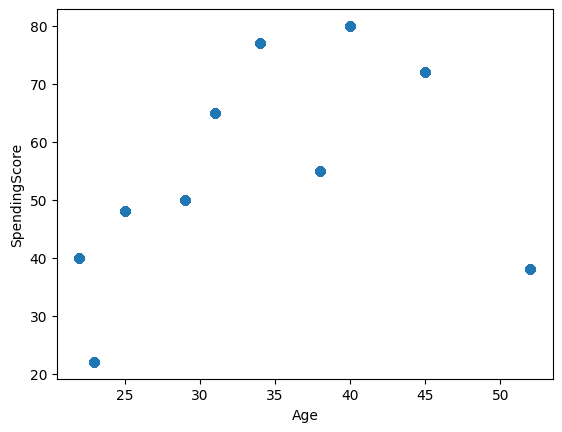

In [73]:
#Age vs Spending score
plt.scatter(df['AGE'],df['SpendingScore'])
plt.xlabel("Age")
plt.ylabel("SpendingScore")
plt.show()

Activity 5

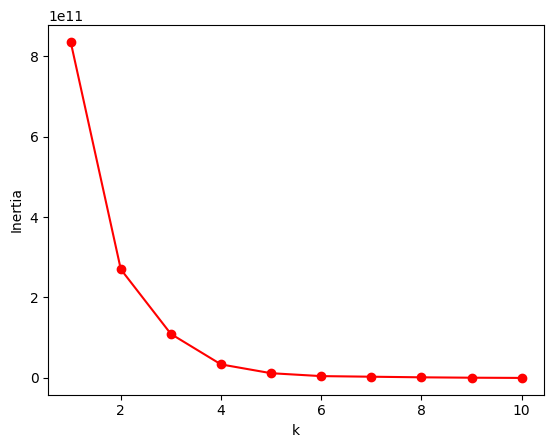

In [79]:
inertia_list=[]
for k in range(1,11):
    model=KMeans(n_clusters=k,random_state=42)
    model.fit(df)
    inertia_list.append(model.inertia_)
#Elbow method
plt.plot(range(1,11),inertia_list,'-o',color='r')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

Activity 6


In [75]:
#Apply with selected k
k=5
model= KMeans(n_clusters=k, random_state=42)
df['Cluster'] = model.fit_predict(X_scaled)


Activity 7


In [76]:
#Cluster center analysis
centers=pd.DataFrame(model.cluster_centers_)
print(centers)

         0         1         2         3         4             5         6   \
0  0.811593  0.451104  0.493938  0.828417  0.981981 -4.625929e-20  0.846415   
1 -1.128400 -1.191572 -1.012199  0.039448 -0.836502 -1.138550e+00 -0.211604   
2  0.010679  0.299472  1.251684  1.538488  1.527525  4.879500e-01 -0.211604   
3 -0.060514  0.122569  0.578132 -0.591726  0.254588  4.879500e-01  0.258627   
4  1.932874  2.005328 -0.937359 -1.538488 -1.745743  1.463850e+00 -1.622295   

         7         8         9         10  
0 -0.500000 -0.500000 -0.500000 -0.333333  
1  0.333333 -0.500000  0.333333 -0.333333  
2  2.000000 -0.500000 -0.500000 -0.333333  
3 -0.500000  1.166667 -0.500000  0.777778  
4 -0.500000 -0.500000  2.000000 -0.333333  


Activity 8

<Axes: xlabel='AnnualIncome', ylabel='SpendingScore'>

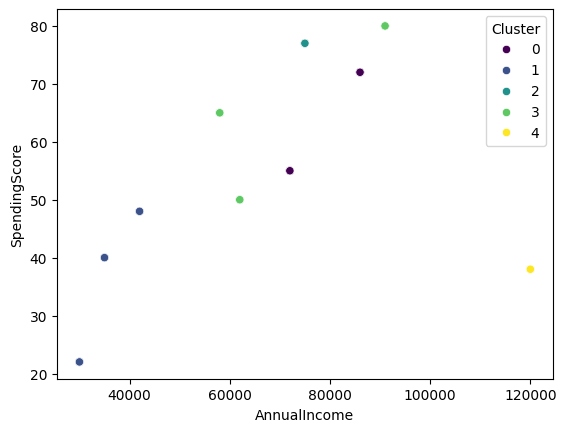

In [77]:
#2D Visualization
import seaborn as sns
sns.scatterplot(x="AnnualIncome", y="SpendingScore",
                hue="Cluster", data=df, palette="viridis")


Activity 9

<Axes: xlabel='PCA1', ylabel='PCA2'>

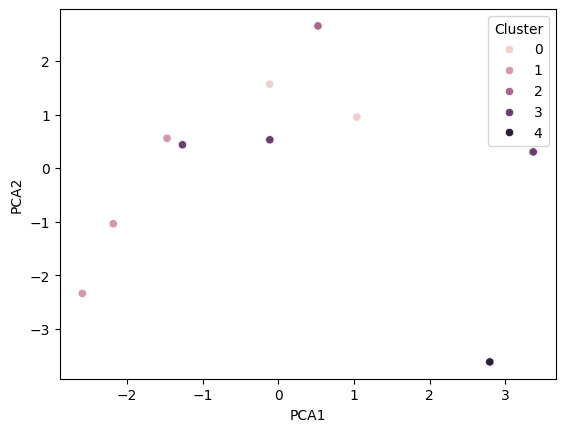

In [78]:
#PCA For 2D plotting
pca=PCA(2)
X_PCA=pca.fit_transform(X_scaled)
df['PCA1']=X_PCA[:,0]
df['PCA2']=X_PCA[:,1]
#Scatter plot
sns.scatterplot(x="PCA1",y="PCA2",hue="Cluster",data=df)